<a href="https://colab.research.google.com/github/giveyourselfaTRY/phototaxis-pomdp-crn/blob/main/01_Single_source_simulations_POMDP_and_CRN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install crnsimulator
from pathlib import Path
import sys, subprocess, os

REPO_NAME = "phototaxis-pomdp-crn"
REPO_URL = "https://github.com/giveyourselfaTRY/phototaxis-pomdp-crn.git"

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path(f"/content/{REPO_NAME}")
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    os.chdir(ROOT)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
else:
    ROOT = Path.cwd().resolve()
    if ROOT.name != REPO_NAME and (ROOT / REPO_NAME).exists():
        ROOT = ROOT / REPO_NAME

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import crnsimulator
from crnsimulator import ReactionGraph

#Single-source numerical trajectory simulation

In [ ]:
import torch
import numpy as np
import math

def normalize_t(T):
    sh= T.shape
    out= torch.einsum('...ij,k->...kj',T,torch.ones(sh[-2]))

    return T/out


def init_random_transition(n,m,a):
    #n number of states of hidden state
    #m number of of observations
    # a number of actions
    T= torch.ones([a,n,n])
    Z=torch.ones([m,m,n])
    return normalize_t(T),normalize_t(Z)



def mutual_information(b: torch.Tensor, ZZ: torch.Tensor) -> torch.Tensor:
    """
    b: (n,) torch tensor (belief / prior)
    ZZ: either (m,m,n) or (m*m,n) emission matrix (columns sum to 1)
    returns: scalar torch tensor
    """
    # Unify dtype/device to match ZZ.
    b = b.to(dtype=ZZ.dtype, device=ZZ.device)

    # Flatten to (m*m, n).
    if ZZ.dim() == 3:
        m1, m2, n = ZZ.shape
        Z = ZZ.reshape(m1*m2, n)
    else:
        Z = ZZ
        n = Z.shape[1]

    # Column-normalize (safety).
    Z = Z / torch.clamp(Z.sum(dim=0, keepdim=True), min=1e-12)

    # Marginal o = Z b.
    o = Z @ b  # (m*m,)


    # term = sum_h b_h sum_v Z[v,h] log Z[v,h] - sum_v o_v log o_v
    logZ = torch.log(torch.clamp(Z, min=1e-12))
    col_term = (Z * logZ).sum(dim=0)        # (n,)
    term2 = (b * col_term).sum() - (o * torch.log(torch.clamp(o, min=1e-12))).sum()
    return term2





def pol(TT,ZZ,b0,r,hyper):
    sh=TT.shape
    V=torch.zeros(sh[0])
    term1=np.zeros(2)
    for i in range(sh[0]):

        term1[i]=r@TT[i]@b0
        term2=mutual_information(TT[i]@b0,ZZ)


        V[i]= term1[i]+ hyper*term2


    return V.argmax(),term1,term2


def update(b,o,a,TT,ZZ):
    #update belief
    v=np.zeros(len(b))
    o1=o[0]
    o2=o[1]
    for i in range(len(b)):
        v[i]=ZZ[o1,o2,i]*b[i]
    return v/v.sum()

In [ ]:

def logistic(x):
    return x>=0

def init_transition(n,m,a):
    #n number of states of hidden state
    #m number of observations
    # a number of actions
    T= torch.zeros([a,n,n])
    Z=torch.zeros([m,m,n])



    T[0]= torch.eye(n)
    T= T+0.1*torch.ones([a,n,n])
    bins_center_obs=np.linspace(0, 1, m+1)


    for i in range(n):


        theta= 2*math.pi*i/n

        observation1= max(math.sin(theta),0)*logistic(100*(math.cos(theta)+0.01))
        observation2= max(-math.sin(theta),0)*logistic(100*(math.cos(theta)+0.01))

        observation1_b = np.digitize(observation1,bins_center_obs)-1
        observation2_b = np.digitize(observation2, bins_center_obs)-1

        Z[observation1_b,observation2_b,i]=10
    Z= Z+0.1*torch.ones([m,m,n])
    Z=Z.reshape(m**2,n)
    Z=normalize_t(Z).reshape(m,m,n)
    return normalize_t(T),Z


In [ ]:


def observation(initial_position,position_light_source,speed_velocity,n,m):
    #n number of states,
    #m number of observation
    #computing the states
    theta_dir= (position_light_source-initial_position)/np.sqrt((position_light_source-initial_position)@(position_light_source-initial_position))
    #direction of light source with respect to reference frame of alga
    direction=speed_velocity/(np.sqrt(speed_velocity@speed_velocity))
    orthogonal1 = np.array([-direction[1],direction[0]])
    orthogonal2=-orthogonal1

    state=direction@theta_dir

    bins_center_obs=np.linspace(0, 1, m+1)



    observation1= max(orthogonal1@theta_dir,0)*logistic(100*(state+0.01))
    observation2= max(orthogonal2@theta_dir,0)*logistic(100*(state+0.01))

    observation1_b = np.digitize(observation1,bins_center_obs)-1
    observation2_b = np.digitize(observation2, bins_center_obs)-1

    obs_out= np.array([observation1_b,observation2_b])

    return obs_out



def simu_env(x,v,a):
    #simulation de l'environement en fonction des actions
    #x position de l'algue,
    #xl position de la lumiere
    #v la direction de vitesse de l'algue
    #a l'action, run (0), tumble (1)

    # add randomness
    noise=0.4*(2*np.random.rand(2)-1)

    if a==1: #choice of a random direction
        vv= 2*np.random.rand(2)-1
        vv= vv/np.sqrt(vv@vv)
        vv=vv+noise
        xx=x.copy()
    else:
        vv=v
        vv=vv+noise
        vv=vv/np.sqrt(vv@vv)
        xx=x+vv

    #xx= x+vv

    # vv=vv+noise

    # xx= x+vv
    return (xx,vv)


In [ ]:

def simu_with_env(r,TT,ZZ,hyper):

    x=np.array([0,0])
    xl=np.array([100,100])

    v=np.array([1,0])



    n=TT.shape[1]
    m=ZZ.shape[0]

    b0=np.ones(TT.shape[1])
    b0= b0/b0.sum()
    b0=torch.tensor(b0)

    o=observation(x,xl,v,n,m)
    a=0
    actions=[a]
    observ=[o]
    beliefs=[b0]
    poss=[x]
    vitesse=[v]
    term1l=[]
    term2l=[]
    for i in range(4000):

        b1=update(b0,o,a,TT,ZZ)
        # print(b1)
        a,term1,term2=pol(TT,ZZ,b1,r,hyper)

        term1l.append(term1) #will be used to find the range of hyper parameters
        term2l.append(term2) #will be used to find the range of hyper parameters


        beliefs.append(b1)
        actions.append(a)

        x,v=simu_env(x,v,a)

        o=observation(x,xl,v,n,m)
        poss.append(x)
        vitesse.append(v)
        observ.append(o)

    acts = np.asarray(actions[1:], dtype=int)
    tumble_count = int((acts == 1).sum())
    total_steps = acts.size
    tumble_ratio = float(tumble_count / total_steps) if total_steps > 0 else 0.0


    stats = {
        "tumble_count": tumble_count,
        "total_steps": total_steps,
        "tumble_ratio": tumble_ratio
    }
    return (actions,observ,beliefs,poss,vitesse,xl,term1l,term2l, stats)



In [ ]:

# Possible hyperparameter with respect to number of states and observations

#Example 1
# hyper=0.34 # ou 9.14
# n=101
# m=3

#Example 2
#hyper=9.13
#n=5
#m=3

#Example 3
#hyper=18
#n=5
#m=3

#Example 4
hyper=0.3
n=5
m=2


r=torch.zeros(n)
#r[math.floor(n/2)]= 10
#r[math.floor(n/2)+1]= 5
r[0]=10
r[1]=8
#r[2]=6
#r[3]=10
a=2
TT,ZZ= init_transition(n,m,a)

/tmp/ipython-input-688000413.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1[i]=r@TT[i]@b0
/tmp/ipython-input-688000413.py:63: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2=mutual_information(TT[i]@b0,ZZ)


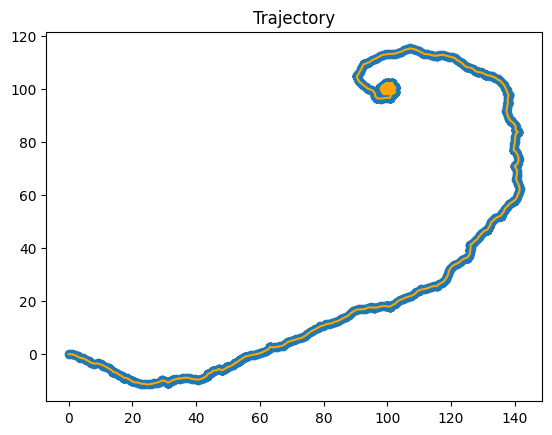

In [ ]:


aa,bb,cc,dd,ee,xl,tl1,tl2,stats=simu_with_env(r,TT,ZZ,hyper)

import matplotlib.pyplot as plt


dd1=np.array(dd)
plt.scatter(dd1[:,0], dd1[:,1])
plt.scatter(xl[0],xl[1], color='red')
plt.plot(dd1[:,0], dd1[:,1], color='orange')
plt.title('Trajectory')
plt.show()

In [ ]:
stats

{'tumble_count': 3156, 'total_steps': 4000, 'tumble_ratio': 0.789}

In [ ]:

list_div=[]
for i in range(len(tl1)):
    add= np.array(tl1)[i].mean()/tl2[i]
    list_div.append(add)
list_div=np.array(list_div)
hyper=list_div.mean()


hyper

np.float32(4.372167)

# CRN-ODE

The parameters modeled before seem to not separate the two actions so I'm building only one CRN-ODE here

In [ ]:
obs_states = ["WW", "RS","LS", "SS"]  # v=0,1,2,3
# (o1,o2) → label.
def obs_label(o1, o2):
    if   (o1, o2) == (0,0): return "WW"  # both weak
    elif (o1, o2) == (0,1): return "RS"  # left strong (right weak)
    elif (o1, o2) == (1,0): return "LS"  # right strong (left weak)
    elif (o1, o2) == (1,1): return "SS"  # both strong
    else: raise ValueError((o1,o2))


actions = [int(a) for a in aa]                  # 0/1
obs_pairs = [tuple(map(int, o)) for o in bb]    # (o1,o2)

# Split directly by matching time indices.
run_labels    = [obs_label(*obs_pairs[t]) for t in range(len(actions)) if actions[t] == 0]
tumble_labels = [obs_label(*obs_pairs[t]) for t in range(len(actions)) if actions[t] == 1]


## get parameters

In [ ]:
# hidden_states=['H1','H2']
hidden_states_run = [f'H{i+1}' for i in range(n)]
hidden_states_tumble = [f'H{i+1}' for i in range(n)]



TT_np = TT.detach().cpu().numpy()
ZZ_np = ZZ.detach().cpu().numpy()

# Then pick the transition matrix corresponding to the action.
T_run    = TT_np[0].copy()  # (n, n)
T_tumble = TT_np[1].copy()

Z_flat = ZZ_np.reshape(m*m, n)
Z_flat = Z_flat / Z_flat.sum(axis=0, keepdims=True)

Z_run  = Z_flat.copy()
Z_tumble = Z_flat.copy()

# Initial distribution.
pi0 = np.ones(n) / n
pi0_run    = pi0.copy()
pi0_tumble = pi0.copy()

In [ ]:
r = r.detach().cpu().numpy()  # shape (n,)
w_run = T_run.T @ r           # shape (n,)
w_tumble = T_tumble.T @ r     # shape (n,)

print('w(run):', w_run)
print('w(tumble):', w_tumble)


w(run): [7.8666663 6.533333  1.1999999 1.1999999 1.1999999]
w(tumble): [3.6 3.6 3.6 3.6 3.6]


In [ ]:
c = (Z_flat**2).sum(axis=0)   # shape = (n,)
c_run=T_run.T @ c
c_tumble=T_tumble.T @ c

print('c(run):', c_run)
print('c(tumble):', c_tumble)

c(run): [0.9434172 0.9434171 0.9434172 0.9434172 0.9434172]
c(tumble): [0.94341725 0.94341725 0.94341725 0.94341725 0.94341725]


## CRN

Need to redesign the CRN.

In [ ]:
def print_crn_reactions(Tr):
  for j, rxn in enumerate(Tr):
    reactants='+'.join(rxn[0])
    products='+'.join(rxn[1])
    rate=rxn[2]
    print(f"{j+1}. {reactants} --> {products} (rate: {rate})")


In [ ]:
class CRN:
    def __init__(self, H, S, T=[]):
        self.H = H         # Hidden states.
        self.S = S         # Observation states.
        self.T = T
        self.ECRN = []
        self.EMCRN = []
        self.Ob = []

    def Obs(self, D):
        """Record observation pair (o1,o2) -> index v"""
        self.Ob = []
        for i in D:
            self.Ob.append(self.S.index(i) + 1)

    def EProj_with_E(self, Z,m):
        """
        One-step Bayes update with E:
        b' ∝ Z[o,h] * b(h)

        Corresponding reaction:
          A_h1 + E_v -> A_h1 + U_h1 + E_v   (rate = Z[v,h])
          M + U_h1   -> A_h2 + U_h1
        """
        self.ECRN = []
        n = len(self.H)
        V = m*m   # Number of all possible observation pairs.

        # Observation-dependent reaction: A_h1 + E_v -> A_h1 + U_h1 + E_v
        for v in range(1, V+1):
            for h in range(1, n+1):
                Ah = f"A{h}_1"
                Uh = f"U{h}_1"
                Ev = f"E{v}_1"   # Use E to represent the observation.
                rate = float(Z[v-1, h-1])   # Z[v,h]
                self.ECRN.append(([Ah, Ev], [Ah, Uh, Ev], rate))

        # Normalization reaction: M + U_h1 -> A_h2 + U_h1
        for h in range(1, n+1):
            Uh  = f"U{h}_1"
            Ah2 = f"A{h}_2"
            self.ECRN.append((["M", Uh], [Ah2, Uh], 1.0))

        return self.ECRN

    def EM(self, Z, m):
        """Observation update with E"""
        self.ECRN = []
        self.EMCRN = self.EProj_with_E(Z,m)
        return self.EMCRN


In [ ]:
# ============ RUN ==============
R_run = CRN(hidden_states_run, obs_states)
R_run.Ob = (run_labels[0], run_labels[1])   # Record observation.

# Build CRN with E.
Tr_run = R_run.EM(Z_run, m)

# Add reward reactions & curiosity reactions.
reward_reactions_run=[]
curiosity_reactions_run=[]
for j in range(n):
    a2=f'A{j+1}_2'
    reward_reactions_run.append(([a2],[a2,'R'],w_run[j]))
    curiosity_reactions_run.append(([a2],[a2,f'C_{j+1}'],c_run[j]))

Tr_run += reward_reactions_run
Tr_run += curiosity_reactions_run

RG_run=ReactionGraph(Tr_run)
print_crn_reactions(Tr_run)
filename_r,odename_r=RG_run.write_ODE_lib(filename='ReactionSimulator_run.py')


1. A1_1+E1_1 --> A1_1+U1_1+E1_1 (rate: 0.9711539149284363)
2. A2_1+E1_1 --> A2_1+U2_1+E1_1 (rate: 0.009615384042263031)
3. A3_1+E1_1 --> A3_1+U3_1+E1_1 (rate: 0.9711539149284363)
4. A4_1+E1_1 --> A4_1+U4_1+E1_1 (rate: 0.9711539149284363)
5. A5_1+E1_1 --> A5_1+U5_1+E1_1 (rate: 0.009615384973585606)
6. A1_1+E2_1 --> A1_1+U1_1+E2_1 (rate: 0.009615384973585606)
7. A2_1+E2_1 --> A2_1+U2_1+E2_1 (rate: 0.009615384042263031)
8. A3_1+E2_1 --> A3_1+U3_1+E2_1 (rate: 0.009615384973585606)
9. A4_1+E2_1 --> A4_1+U4_1+E2_1 (rate: 0.009615384973585606)
10. A5_1+E2_1 --> A5_1+U5_1+E2_1 (rate: 0.9711539149284363)
11. A1_1+E3_1 --> A1_1+U1_1+E3_1 (rate: 0.009615384973585606)
12. A2_1+E3_1 --> A2_1+U2_1+E3_1 (rate: 0.9711538553237915)
13. A3_1+E3_1 --> A3_1+U3_1+E3_1 (rate: 0.009615384973585606)
14. A4_1+E3_1 --> A4_1+U4_1+E3_1 (rate: 0.009615384973585606)
15. A5_1+E3_1 --> A5_1+U5_1+E3_1 (rate: 0.009615384973585606)
16. A1_1+E4_1 --> A1_1+U1_1+E4_1 (rate: 0.009615384973585606)
17. A2_1+E4_1 --> A2_1+U2_1

In [ ]:

R_tumble=CRN(hidden_states_tumble,obs_states)
R_tumble.Ob=(tumble_labels[0],tumble_labels[1])


Tr_tumble=R_tumble.EM(Z_tumble,m)

reward_reactions_tumble=[]
curiosity_reactions_tumble=[]
for j in range(n):
    a2=f'A{j+1}_2'
    reward_reactions_tumble.append(([a2],[a2,'R'],w_tumble[j]))
    curiosity_reactions_tumble.append(([a2],[a2,f'C_{j+1}'],c_tumble[j]))

Tr_tumble+=reward_reactions_tumble
Tr_tumble+=curiosity_reactions_tumble
RG_tumble=ReactionGraph(Tr_tumble)
filename_t,odename_t=RG_tumble.write_ODE_lib(filename=f'ReactionSimulator_tumble.py')
print_crn_reactions(Tr_tumble)






1. A1_1+E1_1 --> A1_1+U1_1+E1_1 (rate: 0.9711539149284363)
2. A2_1+E1_1 --> A2_1+U2_1+E1_1 (rate: 0.009615384042263031)
3. A3_1+E1_1 --> A3_1+U3_1+E1_1 (rate: 0.9711539149284363)
4. A4_1+E1_1 --> A4_1+U4_1+E1_1 (rate: 0.9711539149284363)
5. A5_1+E1_1 --> A5_1+U5_1+E1_1 (rate: 0.009615384973585606)
6. A1_1+E2_1 --> A1_1+U1_1+E2_1 (rate: 0.009615384973585606)
7. A2_1+E2_1 --> A2_1+U2_1+E2_1 (rate: 0.009615384042263031)
8. A3_1+E2_1 --> A3_1+U3_1+E2_1 (rate: 0.009615384973585606)
9. A4_1+E2_1 --> A4_1+U4_1+E2_1 (rate: 0.009615384973585606)
10. A5_1+E2_1 --> A5_1+U5_1+E2_1 (rate: 0.9711539149284363)
11. A1_1+E3_1 --> A1_1+U1_1+E3_1 (rate: 0.009615384973585606)
12. A2_1+E3_1 --> A2_1+U2_1+E3_1 (rate: 0.9711538553237915)
13. A3_1+E3_1 --> A3_1+U3_1+E3_1 (rate: 0.009615384973585606)
14. A4_1+E3_1 --> A4_1+U4_1+E3_1 (rate: 0.009615384973585606)
15. A5_1+E3_1 --> A5_1+U5_1+E3_1 (rate: 0.009615384973585606)
16. A1_1+E4_1 --> A1_1+U1_1+E4_1 (rate: 0.009615384973585606)
17. A2_1+E4_1 --> A2_1+U2_1

In [ ]:
import numpy as np

def init(pi0, T, Z, Ob, obs_states):
    """
    Generate the initial ODE vector I; species order:
      A1_1..A n_1, U1_1..U n_1, A1_2..A n_2, E1_1..E m^2_1, M, R, C_1..C_n

    pi0: initial belief (length n).
    T: (n,n) used only to get n; do not write T into p0 anymore.
    Z: (m^2, n) used only to get m^2; do not write Z into p0 anymore.
    Ob: observation at this step (e.g., 'WW' or its index); only use Ob[0].
    obs_states: list of observation labels (e.g., ["WW","LS","RS","SS"]).
    """
    n  = T.shape[0]
    m2 = Z.shape[0]

    I = []

    # A1_1..A n_1 = pi0
    for i in range(n):
        I.append(float(pi0[i]))



    # A1_2..A n_2 = 0
    for _ in range(n):
        I.append(float(0))

    # E1_1..E m^2_1 : one-hot(obs)
    e = np.zeros(m2, dtype=float)
    o0 = Ob[0]
    idx = obs_states.index(o0) if isinstance(o0, str) else int(o0)
    e[idx] = 1.0
    I.extend(e.tolist())
    print(e)

    # M = 1.0 (normalized resource).
    I.append(1.0)

    # R = 0.0
    I.append(0.0)

    # U1_1..U n_1 = 0
    for _ in range(n):
        I.append(0.0)

    # C_1..C_n = 0
    for _ in range(n):
        I.append(0.0)

    return I


In [ ]:
def initsimulator(n,m,l,I,filename):
    E=[]
    # Belief species.
    for t in range(1,l+1):
        for i in range(1,n+1):
            E.append(f"A{i}_{t}")


    # Observation E species.
    for i in range(1,m*m+1):
          E.append(f"E{i}_1")


    # Reward & transition & curiosity.
    E.append('M')
    E.append('R')

    for i in range(1, n+1):
        E.append(f"U{i}_1")

    for t in range(1,n+1):
        E.append(f"C_{t}")

    # Write ODE header.
    dE = E.copy()
    dE[0]='dA1_1'
    res=[word + 'dt' for word in dE]
    dE=',d'.join(res)
    lines = open(filename).read().splitlines()
    Lstart=1
    for line in lines:
        if line == "def odesystem(p0, t0, r):":
            break
        Lstart+=1
    lines[Lstart]='    '+','.join(E)+'=p0'
    lines[Lstart+4+len(E)]='    return np.array(['+dE+'])'
    Lstart=1
    for line in lines:
        if line == "        logger.warning('Deprecated argument: --pyplot_labels.')":
            break
        Lstart+=1
    lines[Lstart+1]="    svars="+str(E)
    lines[Lstart+3] = "    p0 ="+str(I)
    open(filename,'w').write('\n'.join(lines))
    start=E.index('A1_1')

    return start


In [ ]:

filename_r = "ReactionSimulator_run.py"
filename_t = "ReactionSimulator_tumble.py"
I_run    = init(pi0_run, T_run, Z_run, R_run.Ob,obs_states)
I_tumble = init(pi0_tumble, T_tumble, Z_tumble, R_tumble.Ob,obs_states)

start_r = initsimulator(n, m, 2, I_run, filename_r)
start_t = initsimulator(n, m, 2, I_tumble, filename_t)


In [ ]:
import re
def extract_p0(filename):
    with open(filename) as f:
        text = f.read()
    match = re.search(r'p0\s*=\s*\[([^\]]+)\]', text)
    if match:
        # Use eval to parse the strings like 'np.float64(1.0)'
        p0 = [eval(x) for x in match.group(1).split(',')]
        return p0
    else:
        return None

In [ ]:
f_r = f'ReactionSimulator_run.py'
p0_r = extract_p0(f_r)
print(f"{f_r} p0={p0_r}")

f_t= f'ReactionSimulator_tumble.py'
p0_t = extract_p0(f_t)
print(f"{f_t} p0={p0_t}")


ReactionSimulator_run.py p0=[0.2, 0.2, 0.2, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ReactionSimulator_tumble.py p0=[0.2, 0.2, 0.2, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


# ODE convergence and steady-state analysis

In [ ]:
import re
def extract_svars_from_py(pyfile):
    # extract list for svar
    with open(pyfile, 'r') as f:
        content = f.read()
    svars_line = re.search(r"svars\s*=\s*(\[[^\]]+\])", content)
    if svars_line:
        svars = eval(svars_line.group(1))
        return svars
    else:
        raise RuntimeError("No svars=... line found in file!")

In [ ]:
def extract_conc_curve(datfile, pyfile, targets=('A1_2','A2_2')):
    # Extract concentration curves of A1_2, A2_2 from the .dat file.
    svars = extract_svars_from_py(pyfile)
    idxs = [svars.index(name) for name in targets]
    # First column is time; remaining columns follow svars.
    # print(idxs)
    data = np.loadtxt(datfile)
    time = data[:,0]
    curves = [data[:,i+1] for i in idxs]
    return time, curves


In [ ]:
def detect_convergence(time, curve, threshold=1e-20, window=20):
    diffs = np.abs(np.diff(curve))
    for i in range(len(diffs)-window):
        if np.all(diffs[i:i+window] < threshold):
            return time[i]
    return time[-1]

In [ ]:
def get_convergence_time_for_file(pyfile, datfile, targets=('A1_2','A2_2'),
                                  t8=100.0, delta_t=0.001, plot=False):
    import subprocess
    import numpy as np
    import matplotlib.pyplot as plt

    t_lin = int(t8 / delta_t) + 1
    command = f"python {pyfile} --a 1e-9 --r 1e-9 --t8 {t8} --t-lin {t_lin} --nxy>{datfile}"
    print(f"[DEBUG] Running command: {command}")
    try:
        subprocess.run(command, shell=True, check=True, capture_output=True)
    except subprocess.CalledProcessError as e:
        print(f"[ERROR] Command failed: {command}")
        print(f"[STDERR]\n{e.stderr.decode() if e.stderr else 'no stderr'}")
        print(f"[STDOUT]\n{e.stdout.decode() if e.stdout else 'no stdout'}")
        raise

    # Optional: plot curves separately.
    time, curves = extract_conc_curve(datfile, pyfile, targets)
    t_convs = [detect_convergence(time, curve) for curve in curves]
    if plot:
        plt.figure(figsize=(7,5))
        for c, name in zip(curves, targets):
            plt.plot(time, c, label=name)
        for t_c, name in zip(t_convs, targets):
            plt.axvline(t_c, linestyle='--', label=f"{name} converge at {t_c:.2f}")
        plt.xlabel("Time"); plt.ylabel("Concentration"); plt.yscale('log')
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles)); plt.legend(by_label.values(), by_label.keys())
        plt.title(f"Alpha evolution, T={t8}, delta_t={delta_t}"); plt.grid(True, which="both", ls='--')
        plt.show()

    return t_convs




In [ ]:
def overlay_all_curves_split(
    prefix_run="ReactionSimulator_run",
    prefix_tumble="ReactionSimulator_tumble",
    dat_run="cvgrun_c", dat_tumble="cvgtumble_c",
    targets_run=('A1_2','A2_2','A3_2'),
    targets_tumble=('A1_2','A2_2','A3_2','A4_2','A5_2'),
    t8=100.0, delta_t=0.001
):
    import numpy as np
    import matplotlib.pyplot as plt

    cmap = plt.get_cmap('tab20')
    n_run, n_tum = len(targets_run), len(targets_tumble)
    fig, axes = plt.subplots(max(n_run, n_tum), 2, figsize=(12, 4*max(n_run, n_tum)))
    if max(n_run, n_tum) == 1:
        axes = axes.reshape(1, 2)

    # -- RUN --
    pyfile_r = f'{prefix_run}.py'
    datfile_r = f'{dat_run}.dat'
    t_convs_run = get_convergence_time_for_file(pyfile_r, datfile_r, targets_run, t8, delta_t, plot=False)
    time, curves_run = extract_conc_curve(datfile_r, pyfile_r, targets_run)  # curves_run: list of np.array
    # -- TUMBLE --
    pyfile_t = f'{prefix_tumble}.py'
    datfile_t = f'{dat_tumble}.dat'
    t_convs_tum = get_convergence_time_for_file(pyfile_t, datfile_t, targets_tumble, t8, delta_t, plot=False)
    _,    curves_tum = extract_conc_curve(datfile_t, pyfile_t, targets_tumble)

    # -- plot RUN --
    for j, name in enumerate(targets_run):
        axes[j, 0].plot(time, curves_run[j], color=cmap(j), alpha=0.85, lw=1.5, label='run')
        axes[j, 0].axvline(t_convs_run[j], linestyle='--', color=cmap(j), alpha=0.6, lw=1,
                           label=f'conv @{t_convs_run[j]:.2f}')
        axes[j, 0].set_title(f'{name} - run'); axes[j, 0].set_xlabel('Time'); axes[j, 0].set_ylabel(f'{name}')
        axes[j, 0].set_yscale('log'); axes[j, 0].grid(True, which="both", ls='--')
        handles, labels = axes[j, 0].get_legend_handles_labels()
        axes[j, 0].legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8, ncol=2)

    # -- plot TUMBLE --
    for j, name in enumerate(targets_tumble):
        axes[j, 1].plot(time, curves_tum[j], color=cmap(j+10), alpha=0.85, lw=1.5, label='tumble')
        axes[j, 1].axvline(t_convs_tum[j], linestyle='--', color=cmap(j+10), alpha=0.6, lw=1,
                           label=f'conv @{t_convs_tum[j]:.2f}')
        axes[j, 1].set_title(f'{name} - tumble'); axes[j, 1].set_xlabel('Time'); axes[j, 1].set_ylabel(f'{name}')
        axes[j, 1].set_yscale('log'); axes[j, 1].grid(True, which="both", ls='--')
        handles, labels = axes[j, 1].get_legend_handles_labels()
        axes[j, 1].legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8, ncol=2)

    plt.tight_layout(); plt.show()


In [ ]:
targets_run = tuple([f'A{i+1}_2' for i in range(n)])
targets_tumble = tuple([f'A{i+1}_2' for i in range(n)])

[DEBUG] Running command: python ReactionSimulator_run.py --a 1e-9 --r 1e-9 --t8 1 --t-lin 101 --nxy>cvgrun_c.dat
[DEBUG] Running command: python ReactionSimulator_tumble.py --a 1e-9 --r 1e-9 --t8 1 --t-lin 101 --nxy>cvgtumble_c.dat


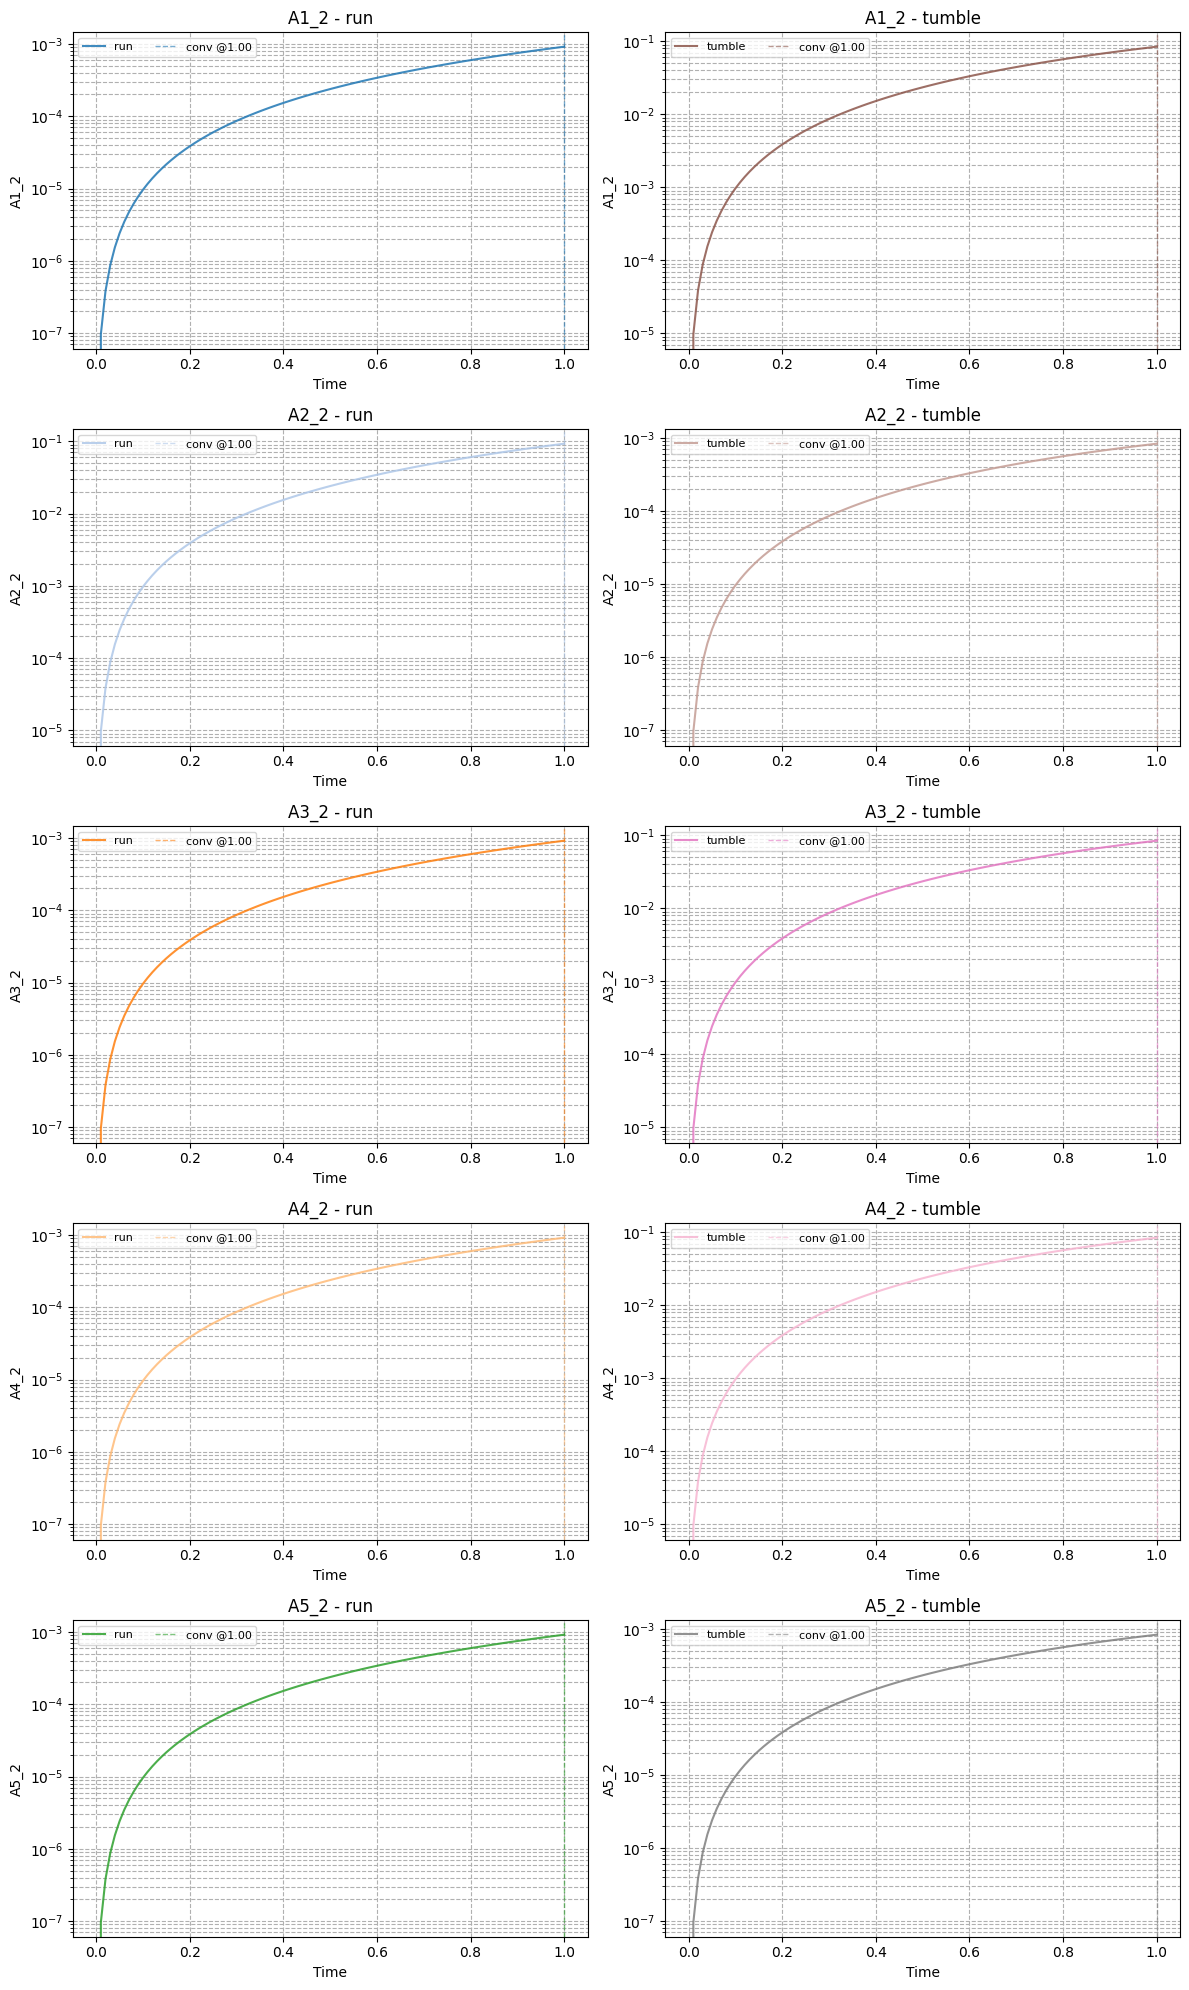

In [ ]:
overlay_all_curves_split(t8=1,delta_t=0.01,
            targets_run=targets_run,
            targets_tumble=targets_tumble)

[DEBUG] Running command: python ReactionSimulator_run.py --a 1e-9 --r 1e-9 --t8 15 --t-lin 15001 --nxy>cvgrun_c.dat
[DEBUG] Running command: python ReactionSimulator_tumble.py --a 1e-9 --r 1e-9 --t8 15 --t-lin 15001 --nxy>cvgtumble_c.dat


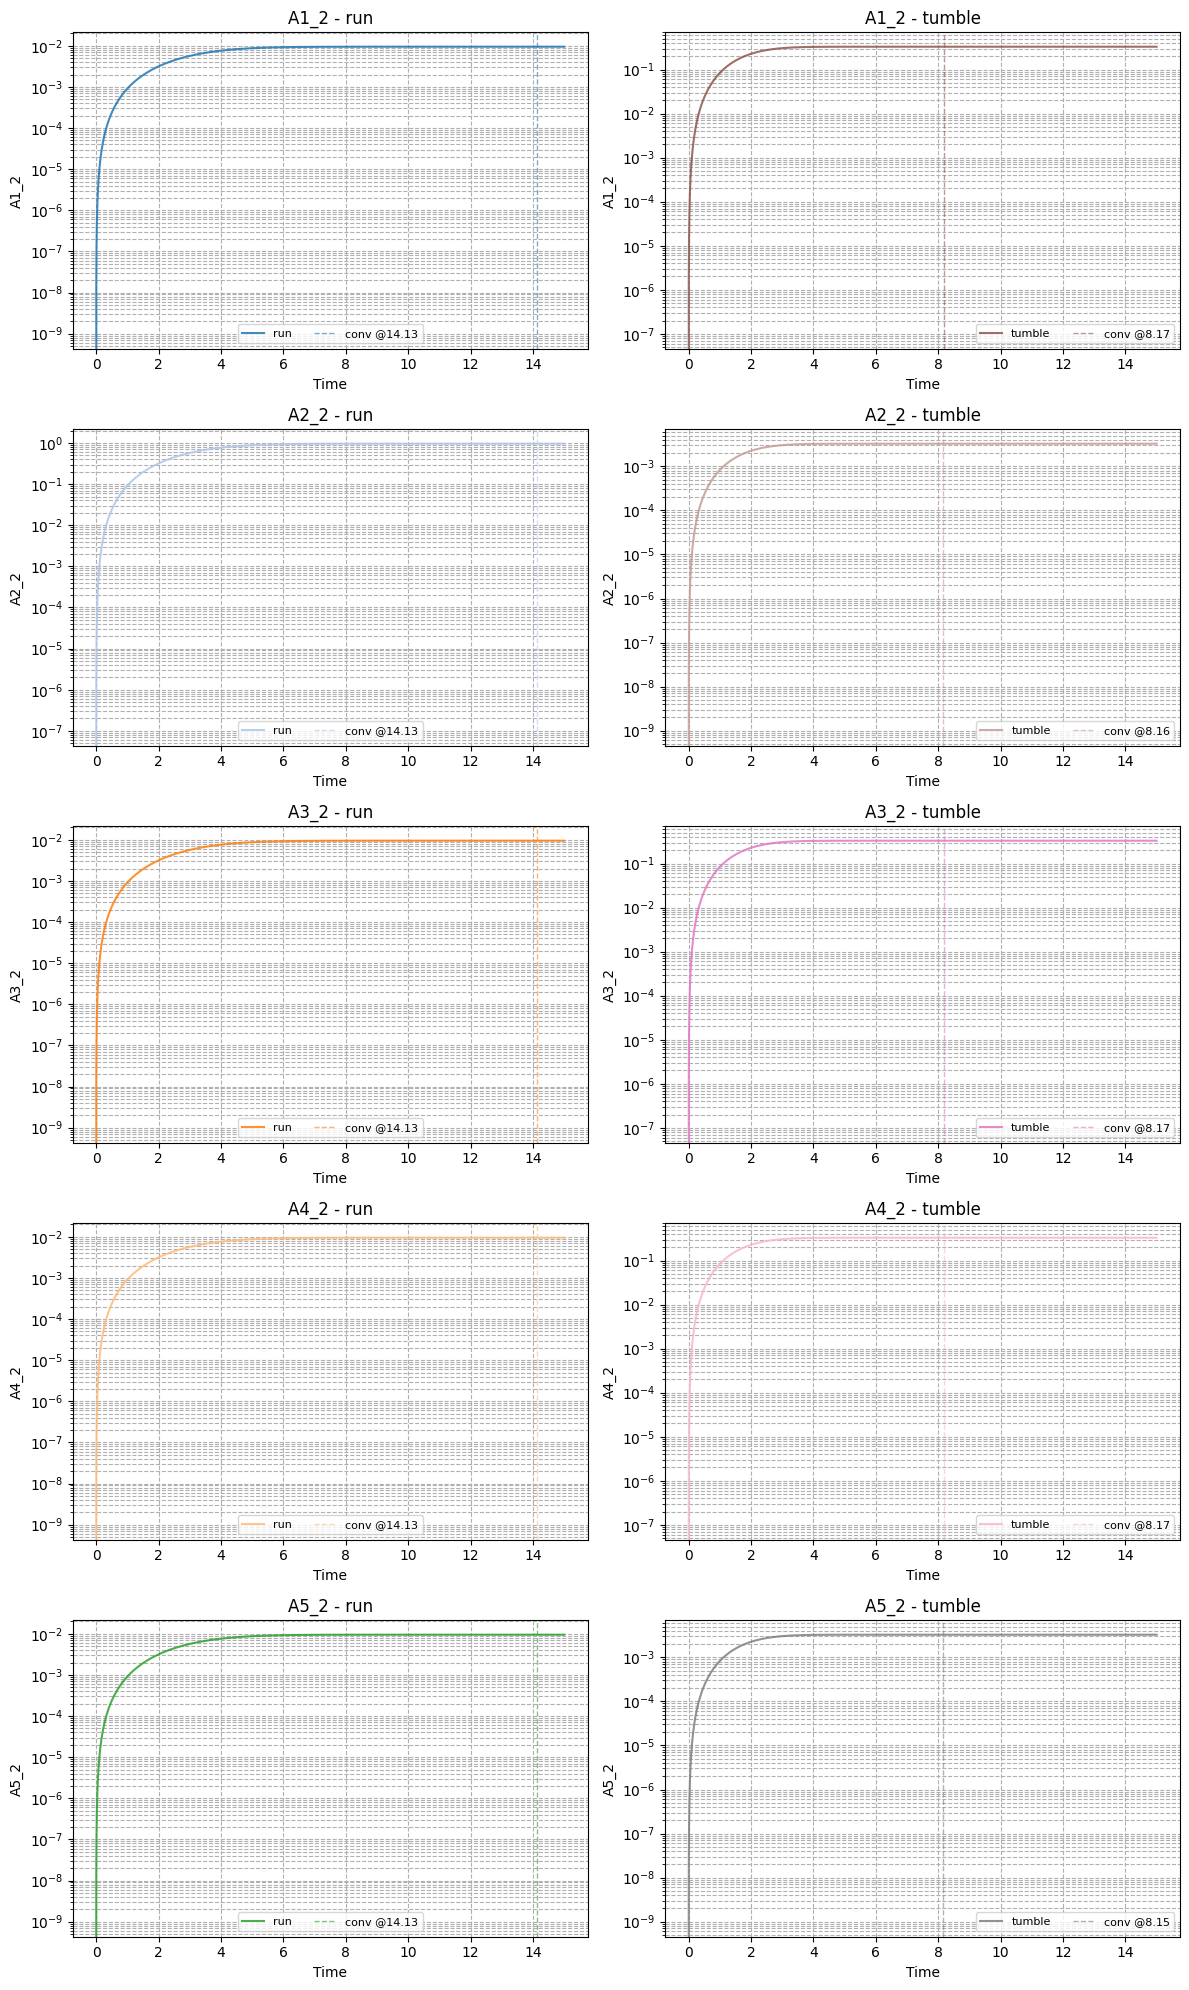

In [ ]:
overlay_all_curves_split(t8=15,
        targets_run=targets_run,
        targets_tumble=targets_tumble)

#### get reward and curiosity

In [ ]:
def extract_final_average(datfile, svars, indices, window=100):
    # Average over the last window time steps to reduce sensitivity to single-step noise.
    import numpy as np
    data = np.loadtxt(datfile)
    # First column of .dat is time; the rest follow svars order.
    vals = data[-window:, [i+1 for i in indices]]  # i+1 skips the time column.
    return np.mean(vals, axis=0)

def extract_final(datfile, svars, indices, window=100):
    data = np.loadtxt(datfile)
    # First column of .dat is time; the rest follow svars order.
    zp_vals = data[-window:, [i+1 for i in indices]]
    time = data[-window:, 0]
    dt = np.diff(time)
    dzp = np.diff(zp_vals, axis=0)  # shape: (window-1, n_zp)
    mean_dzp = np.mean(dzp / dt[:, None], axis=0)  # Mean rate.
    # bound = np.sum(mean_dzp) - 1
    return mean_dzp

In [ ]:
def run_simulator_and_get_rewards(pyfile, datfile, window=100):
    import subprocess
    import numpy as np

    # 1. Run reaction simulator
    command = f"python {pyfile} --a 1e-9 --r 1e-9 --t8 15 --t-lin 15001 --nxy>{datfile}"
    print(f"[DEBUG] Running command: {command}")
    try:
        subprocess.run(command, shell=True, check=True, capture_output=True)
    except subprocess.CalledProcessError as e:
        print(f"[ERROR] Command failed: {command}")
        print(f"[STDERR]\n{e.stderr.decode() if e.stderr else 'no stderr'}")
        print(f"[STDOUT]\n{e.stdout.decode() if e.stdout else 'no stdout'}")
        raise

    # 2. Extract svars
    svars = extract_svars_from_py(pyfile)
    c_indices = [i for i, name in enumerate(svars) if name.startswith('C')]
    r_indices   = [i for i, name in enumerate(svars) if name.startswith('R')]

    # 3. take mean over the steady-state interval.
    # zp_final = extract_final_average(datfile, svars, pos_indices, window=window)
    c_final = extract_final(datfile, svars, c_indices, window=window)
    r_final  = extract_final(datfile, svars, r_indices, window=window)
    # You can use mean - initial value, or directly use the steady-state mean (recommended: steady-state).
    curiosity_val = sum(c_final)+(m*m-2)   # This -1 depends on your definition (your code).
    reward_val    = sum(r_final)
    # a2_indices = [i for i, name in enumerate(svars) if name.startswith("A") and name.endswith("_2")]
    # a2_final = extract_final_average(datfile, svars, a2_indices, window=window)


    return reward_val, curiosity_val


curiosity_weight = hyper
reward_weight = 1.0



pyfile_r = f'ReactionSimulator_run.py'

datfile_r = f'cvgrun_c.dat'
reward_r, curiosity_r = run_simulator_and_get_rewards(pyfile_r, datfile_r)


total_run=reward_weight*reward_r + curiosity_weight*curiosity_r

pyfile_t = f'ReactionSimulator_tumble.py'
datfile_t = f'cvgtumble_c.dat'
reward_t, curiosity_t = run_simulator_and_get_rewards(pyfile_t, datfile_t)

total_tumble=reward_weight*reward_t + curiosity_weight*curiosity_t


print('Reward(run):', reward_r)
print('Curiosity(run):', curiosity_r)
print('Total(run):', total_run)
print('Reward(tumble):', reward_t)
print('Curiosity(tumble):', curiosity_t)
print('Total(tumble):', total_tumble)

if total_run > total_tumble:
    print('Optimal action: run')
else:
    print('Optimal action: tumble')

[DEBUG] Running command: python ReactionSimulator_run.py --a 1e-9 --r 1e-9 --t8 15 --t-lin 15001 --nxy>cvgrun_c.dat
[DEBUG] Running command: python ReactionSimulator_tumble.py --a 1e-9 --r 1e-9 --t8 15 --t-lin 15001 --nxy>cvgtumble_c.dat
Reward(run): 6.3936504040403355
Curiosity(run): 2.9434170787878666
Total(run): 19.301996043611137
Reward(tumble): 3.600000000000001
Curiosity(tumble): 2.9434172512121215
Total(tumble): 16.508346395736787
Optimal action: run


# Numerical vs ODE comparison

In [ ]:
def curiosity_bound_poly(b: torch.Tensor, ZZ: torch.Tensor) -> torch.Tensor:
    """
    Polynomial-style curiosity bound used in CRN:
    sum_{v,h} b_h * Z[v,h]^2 + m^2 - 2
    """
    b = b.to(dtype=ZZ.dtype, device=ZZ.device)

    # reshape Z to (m*m, n)
    if ZZ.dim() == 3:
        m1, m2, n = ZZ.shape
        Z = ZZ.reshape(m1*m2, n)
    else:
        Z = ZZ
        n = Z.shape[1]

    # Column normalization.
    Z = Z / torch.clamp(Z.sum(dim=0, keepdim=True), min=1e-12)

    # Compute sum_{v,h} b_h * Z[v,h]^2
    term1 = (b @ (Z * Z).sum(dim=0)).sum()
    # print('b:',b)


    # m = number of observations.

    bound_val = term1 + (Z.shape[0] - 2)
    return bound_val


In [ ]:

def pol_bound(TT,ZZ,b0,r,hyper):
    sh=TT.shape
    V=torch.zeros(sh[0])
    term1=np.zeros(2)
    for i in range(sh[0]):
        term1[i]=r@TT[i]@b0
        # term2=mutual_information(TT[i]@b0,ZZ)
        term2=curiosity_bound_poly(TT[i]@b0,ZZ)

        # print((TT[i]@b0).shape)
        # print(term2)
        V[i]= term1[i]+ hyper*term2


    return V.argmax(),V,term1,term2

In [ ]:

b0=np.ones(TT.shape[1])
b0= b0/b0.sum()
b0=torch.tensor(b0,dtype=torch.float)
r=torch.tensor(r)
x=np.array([0,0])
xl=np.array([100,100])
v=np.array([1,0])
o=observation(x,xl,v,n,m)


b1=update(b0,o,0,TT,ZZ)
b2=update(b0,o,1,TT,ZZ)
a1,V1,R1,C1=pol_bound(TT,ZZ,b1,r,hyper)
a2,V2,R2,C2=pol_bound(TT,ZZ,b2,r,hyper)




/tmp/ipython-input-2179939805.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r=torch.tensor(r)
/tmp/ipython-input-2869825323.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1[i]=r@TT[i]@b0
/tmp/ipython-input-2869825323.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2=curiosity_bound_poly(TT[i]@b0,ZZ)


In [ ]:
R1[0],C1,R2[1],C2

(np.float64(6.393650322622607),
 tensor(2.9434),
 np.float64(3.5999999046325684),
 tensor(2.9434))

# CRN-guided trajectory under the learned policy

In [ ]:
def replace_p0_in_pyfile(pyfile, p0_list):
    with open(pyfile, 'r') as f:
        lines = f.readlines()
    # Find the line starting with 4 spaces: 'p0 = [...]' (same format as written by init_simulator).
    pat = re.compile(r"^\s*p0\s*=\s*\[")
    for i,line in enumerate(lines):
        if pat.search(line):
            lines[i] = "    p0 =" + str(p0_list) + "\n"
            break
    else:
        raise RuntimeError(f"[{pyfile}] Cannot find 'p0 =' line to replace.")
    with open(pyfile, 'w') as f:
        f.writelines(lines)


In [ ]:
def build_p0_for_step(svars, b_prior, v, n, m):
    """
    svars: species list read from the pyfile (fixed order).
    b_prior: prior of length n (for A*_1).
    v: current observation index (0..m*m-1); use one-hot E_{v+1,1}.
    n: number of hidden states.
    m: number of bins per channel (total observations = m*m).
    """
    p0_map = {}

    # A*_1 = b_prior
    for i in range(1, n+1):
        p0_map[f"A{i}_1"] = float(b_prior[i-1])

    # U*_1 = 0
    for i in range(1, n+1):
        p0_map[f"U{i}_1"] = 0.0

    # A*_2 = 0
    for i in range(1, n+1):
        p0_map[f"A{i}_2"] = 0.0

    # E*_1 one-hot
    for vv in range(1, m*m+1):
        p0_map[f"E{vv}_1"] = 1.0 if vv == (v+1) else 0.0

    # M=1, R=0
    p0_map["M"] = 1.0
    p0_map["R"] = 0.0

    # C_* = 0
    for i in range(1, n+1):
        p0_map[f"C_{i}"] = 0.0

    # If svars contains other names (e.g., legacy variables), set them to 0.
    p0_list = []
    for name in svars:
        p0_list.append(p0_map.get(name, 0.0))
    return p0_list


In [ ]:
def run_one_ode_and_read(pyfile, datfile, b_prior, v, n, m, window=100,
                         t8=15.0, t_lin=15001,curiosity_weight=hyper,reward_weight=1.0):
    """
    1) use b_prior, v to  construct p0 write to pyfile
    2) run ODE → dat
    3) read dat：A*_2 result as belief_next
    """
    # read species order
    svars = extract_svars_from_py(pyfile)
    # construct and write new p0
    p0_list = build_p0_for_step(svars, b_prior, v, n, m)
    replace_p0_in_pyfile(pyfile, p0_list)

    # run simulator

    cmd = f"python {pyfile} --a 1e-9 --r 1e-9 --t8 {t8} --t-lin {t_lin} --nxy>{datfile}"
    import subprocess
    try:
        subprocess.run(cmd, shell=True, check=True, capture_output=True)
    except subprocess.CalledProcessError as e:
        print(f"[ERROR] {pyfile} run failed.")
        print("[STDERR]\n", e.stderr.decode() if e.stderr else "no stderr")
        print("[STDOUT]\n", e.stdout.decode() if e.stdout else "no stdout")
        raise

    # indices
    svars = extract_svars_from_py(pyfile)
    c_indices = [i for i, name in enumerate(svars) if name.startswith('C')]
    r_indices   = [i for i, name in enumerate(svars) if name.startswith('R')]
    a2_idx = [i for i, name in enumerate(svars) if name.startswith("A") and name.endswith("_2")]

    # belief_next
    a2_final = extract_final_average(datfile, svars, a2_idx, window=window)  # shape (n,)
    belief_next = a2_final / max(a2_final.sum(), 1e-12)

    # curiosity and reward
    c_final = extract_final(datfile, svars, c_indices, window=window)
    r_final  = extract_final(datfile, svars, r_indices, window=window)

    curiosity_val = sum(c_final)+(m*m-2)
    reward_val    = sum(r_final)
    total_val=reward_weight*reward_val + curiosity_weight*curiosity_val

    return belief_next, reward_val, curiosity_val,total_val


In [ ]:
from tqdm import tqdm
import torch
import numpy as np

def simu_with_env_crn(r, TT, ZZ, hyper, steps=100, window=100):
    x = np.array([0,0])
    xl = np.array([100,100])
    # v = 2*np.random.rand(2)-1
    v=np.array([1,0])


    n = TT.shape[1]
    m = ZZ.shape[1]
    o = observation(x,xl,v,n,m)

    a = 0

    b0 = np.ones(TT.shape[1]); b0 = b0/b0.sum()
    b0 = torch.tensor(b0, dtype=torch.float)

    actions, beliefs, observ, poss, vitesse = [a],[b0],[o],[x],[v]
    term1l, term2l = [], []   # reward and curiosity.

    # tqdm
    for i in tqdm(range(steps), desc="Simulating"):

        o1, o2 = int(o[0]), int(o[1])
        obs_idx = o1 * m + o2    # m=2 → obs_idx ∈ {0,1,2,3}


        #  action (run / tumble)
        b_r, reward_r, curiosity_r, score_r = run_one_ode_and_read(
            "ReactionSimulator_run.py", "cvgrun_c.dat", b0, obs_idx,n,m,
            reward_weight=1.0, curiosity_weight=hyper, window=window
        )
        b_t, reward_t, curiosity_t, score_t = run_one_ode_and_read(
            "ReactionSimulator_tumble.py", "cvgtumble_c.dat", b0, obs_idx,n,m,
            reward_weight=1.0, curiosity_weight=hyper, window=window
        )

        # choose action
        if i==0:
          a, b1 = 0, b_r
          chosen_score = score_r
        else:
          if score_r >= score_t:
            a, b1 = 0, b_r
            chosen_score = score_r
          else:
            a, b1 = 1, b_t
            chosen_score = score_t


        print(f"[Step {i}] action={a} | run_score={score_r:.4f}, tumble_score={score_t:.4f}, chosen={chosen_score:.4f}")

        # update env

        x, v = simu_env(x, v, a)
        o = observation(x, xl, v, n, m)

        # save
        actions.append(a)
        beliefs.append(torch.tensor(b1))
        observ.append(o)
        poss.append(x)
        vitesse.append(v)
        term1l.append(reward_r if a==0 else reward_t)
        term2l.append(curiosity_r if a==0 else curiosity_t)

    acts = np.asarray(actions[1:], dtype=int)
    tumble_count = int((acts == 1).sum())
    total_steps = acts.size
    tumble_ratio = float(tumble_count / total_steps) if total_steps > 0 else 0.0

    # Append a dict of statistics as an extra return.
    stats = {
        "tumble_count": tumble_count,
        "total_steps": total_steps,
        "tumble_ratio": tumble_ratio
    }
    return (actions,observ,beliefs,poss,vitesse,xl,term1l,term2l, stats)



In [ ]:
aa_crn, bb_crn, cc_crn, dd_crn, ee_crn, xl_crn, tl1_crn, tl2_crn,stats_crn = simu_with_env_crn(r, TT, ZZ, hyper,steps=2000)


Simulating:   0%|          | 1/2000 [00:02<1:22:27,  2.47s/it]

[Step 0] action=0 | run_score=19.3020, tumble_score=16.5083, chosen=19.3020


Simulating:   0%|          | 2/2000 [00:04<1:22:39,  2.48s/it]

[Step 1] action=0 | run_score=19.3020, tumble_score=16.5083, chosen=19.3020


Simulating:   0%|          | 3/2000 [00:07<1:21:53,  2.46s/it]

...

[Step 1997] action=1 | run_score=16.3335, tumble_score=16.5083, chosen=16.5083


Simulating: 100%|█████████▉| 1999/2000 [1:22:28<00:02,  2.46s/it]

[Step 1998] action=1 | run_score=14.2226, tumble_score=16.5083, chosen=16.5083


Simulating: 100%|██████████| 2000/2000 [1:22:31<00:00,  2.48s/it]

[Step 1999] action=1 | run_score=14.2226, tumble_score=16.5083, chosen=16.5083


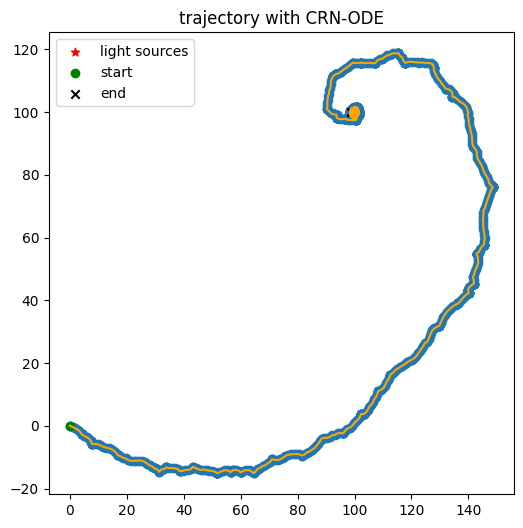

In [ ]:
import matplotlib.pyplot as plt
dd1_crn = np.array(dd_crn)

plt.figure(figsize=(6,6))
plt.scatter(dd1_crn[:,0], dd1_crn[:,1])
plt.scatter(xl_crn[0],xl_crn[1], color='red',marker='*',label='light sources')

plt.plot(dd1_crn[:,0], dd1_crn[:,1], color='orange')
plt.scatter(dd1_crn[0,0],  dd1_crn[0,1],  c='green', marker='o',  label='start')
plt.scatter(dd1_crn[-1,0], dd1_crn[-1,1], c='black', marker='x', label='end')
plt.legend()
plt.title("trajectory with CRN-ODE")
plt.show()

In [ ]:
stats_crn

{'tumble_count': 1463, 'total_steps': 2000, 'tumble_ratio': 0.7315}

## compared with numerical version with curiosity upper bound (how we design CRN)

In [ ]:

def simu_with_envb(r,TT,ZZ,hyper):
    #simulation with environment
    r=torch.tensor(r)
    x=np.array([0,0])
    xl=np.array([100,100])

    v=np.array([1,0])
    # v=2*np.random.rand(2)-1



    n=TT.shape[1]
    m=ZZ.shape[1]
    #b0=np.random.rand(TT.shape[1])
    b0=np.ones(TT.shape[1])
    b0= b0/b0.sum()
    b0=torch.tensor(b0,dtype=torch.float)
    o=observation(x,xl,v,n,m)
    a=0
    actions=[a]
    observ=[o]
    beliefs=[b0]
    poss=[x]
    vitesse=[v]
    term1l=[]
    term2l=[]

    for i in range(4000):
        b1=update(b0,o,a,TT,ZZ)
        a,score,term1,term2=pol_bound(TT,ZZ,b1,r,hyper)
        term1l.append(term1) #will be used to find the range of hyper parameters
        term2l.append(term2) #will be used to find the range of hyper parameters


        beliefs.append(b1)
        actions.append(a)

        x,v=simu_env(x,v,a)
        o=observation(x,xl,v,n,m)
        poss.append(x)
        vitesse.append(v)
        observ.append(o)
    acts = np.asarray(actions[1:], dtype=int)
    tumble_count = int((acts == 1).sum())
    total_steps = acts.size
    tumble_ratio = float(tumble_count / total_steps) if total_steps > 0 else 0.0

    # Append a dict of statistics as an extra return.
    stats = {
        "tumble_count": tumble_count,
        "total_steps": total_steps,
        "tumble_ratio": tumble_ratio
    }
    return (actions,observ,beliefs,poss,vitesse,xl,term1l,term2l, stats)
    # return (actions,observ,beliefs,poss,vitesse,xl,term1l,term2l)


In [ ]:
aab,bbb,ccb,ddb,eeb,xlabelb,tl1b,tl2b,statsb=simu_with_envb(r,TT,ZZ,hyper)


/tmp/ipython-input-2599439791.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r=torch.tensor(r)
/tmp/ipython-input-2869825323.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1[i]=r@TT[i]@b0
/tmp/ipython-input-2869825323.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2=curiosity_bound_poly(TT[i]@b0,ZZ)


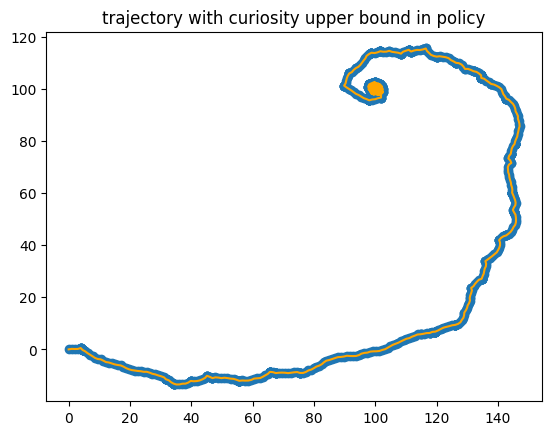

In [ ]:
dd1b=np.array(ddb)
plt.scatter(dd1b[:,0], dd1b[:,1])
plt.scatter(xlabelb[0],xlabelb[1], color='red')
plt.plot(dd1b[:,0], dd1b[:,1], color='orange')
plt.title("trajectory with curiosity upper bound in policy")
plt.show()


In [ ]:
statsb

{'tumble_count': 3145, 'total_steps': 4000, 'tumble_ratio': 0.78625}

# hyperparam search on curiosity weight

In [ ]:
#Methode 2
list_divb=[]
for i in range(len(tl1b)):
    addb= np.array(tl1b)[i].mean()/tl2b[i]
    list_divb.append(addb)
list_divb=np.array(list_divb)
hyperb=list_divb.mean()

#La valeur en sortie donne la valeur d'hyperparamètre à partir duquel on a un comportement de phototaxis

hyperb

np.float32(1.2517569)

In [ ]:
def _pick_for_action(term, a):

    # torch -> numpy
    if isinstance(term, torch.Tensor):
        term = term.detach().cpu().numpy()
    # list/tuple -> ndarray.
    if isinstance(term, (list, tuple)):
        term = np.asarray(term)
    # Scalar
    if np.isscalar(term):
        return float(term)
    # 1D or higher-D: index by a (e.g., term.shape[0] == #actions).
    return float(np.asarray(term, dtype=float)[a])

def _simulate_one_and_metrics(r, TT, ZZ, lam, steps=2000):
    # init
    x  = np.array([0, 0], dtype=float)
    xl = np.array([100, 100], dtype=float)
    v  = np.array([1, 0], dtype=float)

    a  = 0
    n  = TT.shape[1]
    m  = ZZ.shape[1]

    b0 = np.ones(TT.shape[1], dtype=float); b0 = b0 / b0.sum()
    b0 = torch.tensor(b0, dtype=torch.float)
    o  = observation(x, xl, v, n, m)
    actions=[a]
    poss=[x.copy()]
    term1l=[]; term2l=[]

    for _ in range(steps):
        b1 = update(b0, o, a, TT, ZZ)
        a, score, term1, term2 = pol_bound(TT, ZZ, b1, r, lam)
        t1_scalar = _pick_for_action(term1, a)

        term1l.append(t1_scalar)
        term2l.append(term2)

        x, v = simu_env(x, v, a)
        o = observation(x, xl, v, n, m)
        actions.append(a)
        poss.append(x.copy())


    # Metric
    eps = 1e-12
    t1 = np.asarray(term1l, dtype=float)
    t2 = np.asarray(term2l, dtype=float)
    J1 = float(t1.sum()); J2 = float(t2.sum()); J_total = J1 + lam * J2
    t1m = float(np.abs(t1).mean()); t2m = float(np.abs(t2).mean())
    rho = t1m / (lam * (t2m + eps) + eps) if lam > 0 else np.inf

    x0 = np.asarray(poss[0], dtype=float); xT = np.asarray(poss[-1], dtype=float)
    d0 = np.linalg.norm(x0 - xl); dT = np.linalg.norm(xT - xl)
    progress = (d0 - dT) / (d0 + eps)

    acts = np.asarray(actions[1:], dtype=int)
    tumble_ratio = float((acts == 1).mean()) if acts.size > 0 else 0.0

    return dict(progress=progress, tumble_ratio=tumble_ratio,
                J_total=J_total, rho=rho)

# Search 20 λ values on a fixed grid [0,2]; run 100 trajectories per λ; keep the original 'best λ' selection rule.
def hyper_search_fixed_grid_with_plots(r, TT, ZZ,
                                       lam_min=0.0, lam_max=2.0, num_lams=20,
                                       steps=2000, trials=100, tau=1.5,
                                       show_tqdm=True, seed_base=0):
    lam_grid = np.linspace(lam_min, lam_max, num=num_lams, endpoint=True)

    # Collect matrix: each row is a λ; each column is one trial.
    progress_mat = np.zeros((num_lams, trials), dtype=float)
    tumble_mat   = np.zeros((num_lams, trials), dtype=float)
    Jtotal_mat   = np.zeros((num_lams, trials), dtype=float)
    rho_mat      = np.zeros((num_lams, trials), dtype=float)

    outer = tqdm(range(num_lams), desc="Fixed-grid λ search") if show_tqdm else range(num_lams)
    for i in outer:
        lam = float(lam_grid[i])
        if show_tqdm:
            outer.set_postfix_str(f"λ={lam:.3f}")
        inner = tqdm(range(trials), leave=False, desc=f"λ={lam:.3f}") if show_tqdm else range(trials)
        for j in inner:
            # Reproducible
            np.random.seed(seed_base + i*trials + j)
            torch.manual_seed(seed_base + i*trials + j)
            met = _simulate_one_and_metrics(r, TT, ZZ, lam, steps=steps)
            progress_mat[i, j] = met["progress"]
            tumble_mat[i, j]   = met["tumble_ratio"]
            Jtotal_mat[i, j]   = met["J_total"]
            rho_mat[i, j]      = met["rho"]

    # Compute mean (to keep the original selection rule).
    prog_mean = progress_mat.mean(axis=1)
    tumb_mean = tumble_mat.mean(axis=1)
    J_mean    = Jtotal_mat.mean(axis=1)
    rho_mean  = rho_mat.mean(axis=1)

    # — original selection rule — #
    # First filter: ρ ∈ [1/τ, τ]; within the filtered set pick the one with the largest mean J_total; if none, pick the smallest |log ρ|, then the largest J_total.
    idx_ok = np.where((rho_mean >= 1.0/tau) & (rho_mean <= tau))[0]
    if idx_ok.size > 0:
        # Within ok, pick the one with the largest J_mean (optionally use progress as secondary).
        best_idx = int(idx_ok[np.argmax(J_mean[idx_ok])])
    else:
        # Fallback policy: minimize |log ρ|, then maximize J_mean
        order = np.lexsort((-J_mean, np.abs(np.log(rho_mean + 1e-12))))
        best_idx = int(order[0])

    best_lambda = float(lam_grid[best_idx])

    summary = dict(
        lambda_grid = lam_grid,
        progress_mat = progress_mat,
        tumble_mat = tumble_mat,
        Jtotal_mat = Jtotal_mat,
        rho_mat = rho_mat,
        prog_mean = prog_mean,
        tumble_mean = tumb_mean,
        J_mean = J_mean,
        rho_mean = rho_mean,
        best = dict(idx=best_idx, lam=best_lambda,
                    prog=prog_mean[best_idx], tumble=tumb_mean[best_idx],
                    J=J_mean[best_idx], rho=rho_mean[best_idx],
                    tau=tau)
    )
    return summary

# Plot two relationships: progress–λ and tumble_ratio–λ (mean ± std + all scatter points).
def plot_progress_and_tumble_vs_lambda(stats, jitter=0.01):
    lam = stats["lambda_grid"]
    prog = stats["progress_mat"]; prog_mean, prog_std = prog.mean(axis=1), prog.std(axis=1)
    tumb = stats["tumble_mat"];   tumb_mean, tumb_std = tumb.mean(axis=1), tumb.std(axis=1)
    best_lam = stats["best"]["lam"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    # Left: Progress vs λ.
    # Scatter (100 trajectories) with small horizontal jitter for separation.
    for i, l in enumerate(lam):
        x = np.full(prog.shape[1], l) + np.random.uniform(-jitter, jitter, size=prog.shape[1])
        axes[0].scatter(x, prog[i], s=10, alpha=0.25)
    # Mean ± std.
    axes[0].plot(lam, prog_mean, lw=2)
    axes[0].fill_between(lam, prog_mean - prog_std, prog_mean + prog_std, alpha=0.2)
    axes[0].axvline(best_lam, linestyle='--', alpha=0.7, label=f"best λ = {best_lam:.3f}")
    axes[0].set_xlabel("lambda"); axes[0].set_ylabel("progress")
    axes[0].set_title("Progress vs. lambda"); axes[0].legend()

    # Right: Tumble ratio vs λ.
    for i, l in enumerate(lam):
        x = np.full(tumb.shape[1], l) + np.random.uniform(-jitter, jitter, size=tumb.shape[1])
        axes[1].scatter(x, tumb[i], s=10, alpha=0.25)
    axes[1].plot(lam, tumb_mean, lw=2)
    axes[1].fill_between(lam, tumb_mean - tumb_std, tumb_mean + tumb_std, alpha=0.2)
    axes[1].axvline(best_lam, linestyle='--', alpha=0.7, label=f"best λ = {best_lam:.3f}")
    axes[1].set_xlabel("lambda"); axes[1].set_ylabel("tumble ratio")
    axes[1].set_title("Tumble ratio vs. lambda"); axes[1].legend()

    plt.show()





In [ ]:
summary = hyper_search_fixed_grid_with_plots(r, TT, ZZ,
                      lam_min=0.1, lam_max=2.0, num_lams=20,
                      steps=4000, trials=100, tau=1.5,
                      show_tqdm=True, seed_base=0)
print("Best (fixed-grid, original rule):", summary["best"])


λ=0.100:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipython-input-2869825323.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1[i]=r@TT[i]@b0
/tmp/ipython-input-2869825323.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2=curiosity_bound_poly(TT[i]@b0,ZZ)

Fixed-grid λ search: 100%|██████████| 20/20 [2:02:18<00:00, 366.93s/it, λ=2.000]

Best (fixed-grid, original rule): {'idx': 19, 'lam': 2.0, 'prog': np.float64(0.9911420267767411), 'tumble': np.float64(0.7843175000000001), 'J': np.float64(40357.50412936059), 'rho': np.float64(0.7138881387308449), 'tau': 1.5}


In [ ]:
print("Best (fixed-grid, original rule):", summary["best"])

Best (fixed-grid, original rule): {'idx': 19, 'lam': 2.0, 'prog': np.float64(0.9911420267767411), 'tumble': np.float64(0.7843175000000001), 'J': np.float64(40357.50412936059), 'rho': np.float64(0.7138881387308449), 'tau': 1.5}


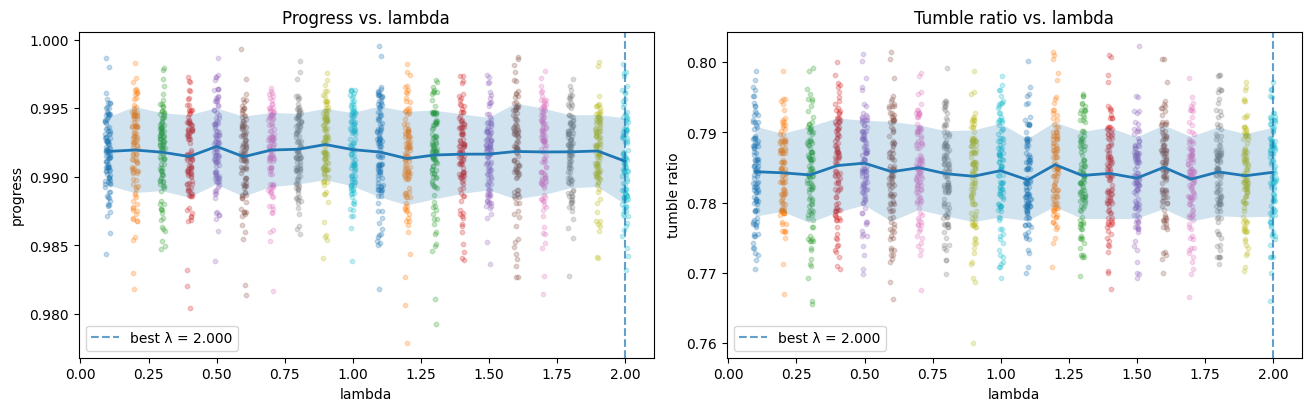

In [ ]:
plot_progress_and_tumble_vs_lambda(summary)

In [ ]:
aabest, bbbest, ccbest, ddbest, eebest, xlbest, term1best, term2best, statsbest= simu_with_envb(
    r, TT, ZZ, hyper=summary["best"]["lam"]
)

/tmp/ipython-input-3567942201.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r=torch.tensor(r)
/tmp/ipython-input-2869825323.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1[i]=r@TT[i]@b0
/tmp/ipython-input-2869825323.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2=curiosity_bound_poly(TT[i]@b0,ZZ)


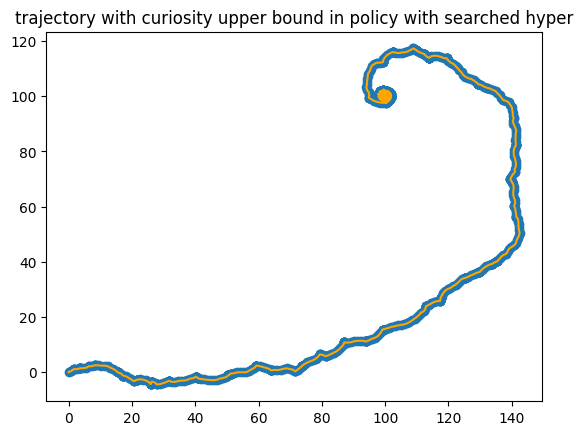

{'tumble_count': 3167, 'total_steps': 4000, 'tumble_ratio': 0.79175}

In [ ]:
dd1best=np.array(ddbest)
plt.scatter(dd1best[:,0], dd1best[:,1])
plt.scatter(xlbest[0],xlbest[1], color='red')
plt.plot(dd1best[:,0], dd1best[:,1], color='orange')
plt.title("trajectory with curiosity upper bound in policy with searched hyper")
plt.show()
statsbest

In [ ]:
aa_crnbest, bb_crnbest, cc_crnbest, dd_crnbest, ee_crnbest, xl_crnbest, tl1_crnbest, tl2_crn,stats_crnbest = simu_with_env_crn(r,TT,ZZ,hyper=summary["best"]["lam"],steps=2000)


Simulating:   0%|          | 1/2000 [00:02<1:23:09,  2.50s/it]

[Step 0] action=0 | run_score=12.2805, tumble_score=9.4868, chosen=12.2805


Simulating:   0%|          | 2/2000 [00:04<1:22:43,  2.48s/it]

[Step 1] action=0 | run_score=12.2805, tumble_score=9.4868, chosen=12.2805


Simulating:   0%|          | 3/2000 [00:07<1:21:55,  2.46s/it]

...

[Step 1046] action=1 | run_score=9.3120, tumble_score=9.4868, chosen=9.4868


Simulating:  52%|█████▏    | 1048/2000 [42:47<39:16,  2.48s/it]

[Step 1047] action=1 | run_score=9.3120, tumble_score=9.4868, chosen=9.4868


Simulating:  52%|█████▏    | 1049/2000 [42:49<38:57,  2.46s/it]

[Step 1048] action=1 | run_score=9.3120, tumble_score=9.4868, chosen=9.4868


In [ ]:

dd1_crnbest = np.array(dd_crnbest)

plt.figure(figsize=(6,6))
plt.scatter(dd1_crnbest[:,0], dd1_crnbest[:,1], s=10, label="trajectory")
plt.plot(dd1_crnbest[:,0], dd1_crnbest[:,1], color='orange')
plt.scatter(xl_crnbest[0], xl_crnbest[1], color='red', label="light source")
plt.legend()
plt.title("trajectory with CRN-ODE and searched hyper ")
plt.show()
stats_crnbest